# Build 04 — Intervention Analysis

> *DiD + RDD + PSM: Quasi-Experimental Identification Using Model Version Changes*

**EN:** Each model-version deployment becomes a natural experiment. Three complementary strategies: (1) DiD compares pre/post deployment with treated/control, (2) RDD exploits the sharp investigation threshold, (3) PSM matches investigated/uninvestigated on observables.

**KR:** 각 모델 버전 배포를 자연 실험으로 취급. 세 가지 보완 전략: (1) DiD는 사전/사후 + treated/control, (2) RDD는 가파른 조사 임계값을 활용, (3) PSM은 관측변수에서 조사/미조사 매칭.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Difference-in-Differences (DiD)

**EN:** Subtracts the control's pre→post change from the treated's. Key assumption: parallel trends.

**KR:** control의 사전→사후 변화를 treated에서 뺌. 핵심 가정: parallel trends.

In [2]:
def difference_in_differences(
    df: pd.DataFrame,
    version_col: str,        # Column indicating model version period (e.g. 'model_period')
    pre_version: str,        # Value of version_col for pre-period
    post_version: str,       # Value of version_col for post-period
    treatment_col: str,      # Binary: above/below threshold
    outcome_col: str,        # Fraud label (binary)
) -> dict:
    """
    Difference-in-Differences estimator.

    Setup:
        Pre-period  = model v1 in deployment
        Post-period = model v2 in deployment
        Treatment   = claim scored above investigation threshold
        Control     = claim scored below threshold
        Outcome     = fraud label

    DiD estimate = (E[Y|treated,post] - E[Y|treated,pre])
                  - (E[Y|control,post] - E[Y|control,pre])

    Interpretation:
        DiD ≠ 0 means: the model version change causally shifted fraud
        detection patterns (beyond what would have changed anyway in
        the control group)
    """
    pre_mask = df[version_col] == pre_version
    post_mask = df[version_col] == post_version
    treated_mask = df[treatment_col] == 1
    control_mask = df[treatment_col] == 0

    # Four cells
    y_treated_pre = df.loc[pre_mask & treated_mask, outcome_col].dropna().mean()
    y_treated_post = df.loc[post_mask & treated_mask, outcome_col].dropna().mean()
    y_control_pre = df.loc[pre_mask & control_mask, outcome_col].dropna().mean()
    y_control_post = df.loc[post_mask & control_mask, outcome_col].dropna().mean()

    # DiD estimate
    did_estimate = (y_treated_post - y_treated_pre) - (y_control_post - y_control_pre)

    # Standard error via delta method (approximate)
    n_tp = (pre_mask & treated_mask).sum()
    n_tpost = (post_mask & treated_mask).sum()
    n_cp = (pre_mask & control_mask).sum()
    n_cpost = (post_mask & control_mask).sum()

    # SE using binomial variance approximation
    se = np.sqrt(
        y_treated_pre * (1 - y_treated_pre) / max(n_tp, 1) +
        y_treated_post * (1 - y_treated_post) / max(n_tpost, 1) +
        y_control_pre * (1 - y_control_pre) / max(n_cp, 1) +
        y_control_post * (1 - y_control_post) / max(n_cpost, 1)
    )
    z_stat = did_estimate / se if se > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(z_stat)))

    return {
        'y_treated_pre': round(y_treated_pre, 4),
        'y_treated_post': round(y_treated_post, 4),
        'y_control_pre': round(y_control_pre, 4),
        'y_control_post': round(y_control_post, 4),
        'did_estimate': round(did_estimate, 4),
        'std_error': round(se, 4),
        'z_statistic': round(z_stat, 3),
        'p_value': round(p_value, 4),
        'significant': p_value < 0.05,
        'interpretation': (
            f"Model version change {'causally shifted' if p_value < 0.05 else 'did NOT significantly shift'} "
            f"fraud detection by {did_estimate:+.3f} (p={p_value:.3f})"
        )
    }

## 3. Regression Discontinuity Design (RDD)

In [3]:
def regression_discontinuity(
    df: pd.DataFrame,
    score_col: str,
    threshold: float,
    outcome_col: str,
    bandwidth: float = None,
    n_bins: int = 20,
) -> dict:
    """
    Regression Discontinuity Design at the investigation score threshold.

    Intuition:
        Claims scored just above the threshold are VERY similar to claims
        just below it (same true risk, same features), but:
        - Just above: investigated → fraud label observed
        - Just below: not investigated → fraud label NOT observed

        The jump in fraud discovery rate at the threshold is:
            (a) Due to investigation causing fraud discovery, OR
            (b) Due to genuinely riskier claims being just above threshold

        RDD measures the LOCAL causal effect of investigation.

    If the jump is large relative to the overall trend,
    investigation is CAUSING the observed fraud label, not just
    selecting for genuinely riskier claims.
    """
    df = df.copy()
    df['running_var'] = df[score_col] - threshold  # centered at threshold

    if bandwidth is None:
        bandwidth = df['running_var'].std() * 0.5

    # Local sample around threshold
    local_mask = df['running_var'].abs() <= bandwidth
    local_df = df[local_mask].copy()

    if len(local_df) < 50:
        return {'error': f'Insufficient data near threshold (n={len(local_df)}). Increase bandwidth.'}

    treated = local_df['running_var'] >= 0   # above threshold
    control = local_df['running_var'] < 0    # below threshold

    # Outcomes near threshold
    y_just_above = local_df.loc[treated, outcome_col].dropna().mean()
    y_just_below = local_df.loc[control, outcome_col].dropna().mean()
    rdd_estimate = y_just_above - y_just_below

    # Test significance
    above_outcomes = local_df.loc[treated, outcome_col].dropna()
    below_outcomes = local_df.loc[control, outcome_col].dropna()

    t_stat, p_value = stats.ttest_ind(above_outcomes, below_outcomes)

    # Binned visualization data
    df['score_bin'] = pd.cut(df[score_col], bins=n_bins)
    bin_stats = df.groupby('score_bin', observed=True).agg(
        mean_outcome=(outcome_col, 'mean'),
        n_claims=(outcome_col, 'count'),
        mean_score=(score_col, 'mean')
    ).reset_index().dropna()

    return {
        'threshold': threshold,
        'bandwidth': round(bandwidth, 4),
        'n_local_sample': len(local_df),
        'n_above': int(treated.sum()),
        'n_below': int(control.sum()),
        'y_just_above_threshold': round(y_just_above, 4),
        'y_just_below_threshold': round(y_just_below, 4),
        'rdd_estimate': round(rdd_estimate, 4),
        't_statistic': round(t_stat, 3),
        'p_value': round(p_value, 4),
        'significant': p_value < 0.05,
        'bin_stats': bin_stats,
        'interpretation': (
            f"At the investigation threshold ({threshold:.3f}), fraud discovery rate "
            f"jumps by {rdd_estimate:+.3f} (p={p_value:.3f}). "
            f"{'This jump CANNOT be explained by claim features alone — investigation causes fraud discovery.' if p_value < 0.05 else 'No significant discontinuity at threshold.'}"
        )
    }

## 4. RDD Visualisation

In [4]:
def plot_rdd(rdd_result: dict, title: str = "RDD: Fraud Rate Around Investigation Threshold"):
    """Visualise the RDD discontinuity."""
    if 'error' in rdd_result:
        print(f"Cannot plot: {rdd_result['error']}")
        return

    bin_stats = rdd_result['bin_stats']
    threshold = rdd_result['threshold']

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(
        bin_stats['mean_score'], bin_stats['mean_outcome'],
        s=bin_stats['n_claims'] / bin_stats['n_claims'].max() * 100,
        alpha=0.7, color='steelblue', label='Fraud rate (bin average)'
    )
    ax.axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Investigation threshold ({threshold:.3f})')

    # Add annotation for jump
    ax.annotate(
        f'RDD estimate: {rdd_result["rdd_estimate"]:+.3f}\n(p={rdd_result["p_value"]:.3f})',
        xy=(threshold, rdd_result['y_just_above_threshold']),
        xytext=(threshold + 0.1, rdd_result['y_just_above_threshold'] + 0.05),
        arrowprops=dict(arrowstyle='->', color='red'),
        fontsize=10, color='red'
    )

    ax.set_xlabel('Model Risk Score')
    ax.set_ylabel('Observed Fraud Rate')
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.savefig('rdd_discontinuity.png', dpi=150)
    plt.show()
    print("Saved: rdd_discontinuity.png")

## 5. Propensity Score Matching (PSM)

In [5]:
def propensity_score_matching(
    df: pd.DataFrame,
    treatment_col: str,      # 'investigated' (1=treated, 0=control)
    outcome_col: str,        # 'observed_fraud'
    feature_cols: list[str],
    n_matches: int = 1,
    caliper: float = 0.05,
) -> dict:
    """
    Propensity Score Matching to estimate Average Treatment Effect (ATE)
    of investigation on fraud discovery.

    If investigation causes fraud discovery (investigation reveals fraud that
    would not otherwise have been detected), then:
        ATE = E[Y(1)] - E[Y(0)] > 0

    But if fraud is truly higher in the investigated group (model is correct),
    then ATE should be approximately 0 (investigation just reveals existing fraud).

    A high ATE means: investigation is CREATING the fraud label, not finding it.
    """
    treated_mask = df[treatment_col] == 1
    control_mask = df[treatment_col] == 0

    # Estimate propensity scores
    X = df[feature_cols].values
    y = df[treatment_col].values.astype(int)
    ps_model = LogisticRegression(max_iter=1000)
    ps_model.fit(X, y)
    ps_scores = ps_model.predict_proba(X)[:, 1]
    df = df.copy()
    df['propensity_score'] = ps_scores

    treated_df = df[treated_mask].copy().reset_index(drop=True)
    control_df = df[control_mask].copy().reset_index(drop=True)

    # Nearest-neighbour matching within caliper
    treated_ps = treated_df['propensity_score'].values.reshape(-1, 1)
    control_ps = control_df['propensity_score'].values.reshape(-1, 1)

    nn = NearestNeighbors(n_neighbors=n_matches, metric='euclidean')
    nn.fit(control_ps)
    distances, indices = nn.kneighbors(treated_ps)

    # Filter by caliper
    matched_treated_outcomes = []
    matched_control_outcomes = []
    n_matched = 0

    for i, (dist, idx) in enumerate(zip(distances, indices)):
        if dist[0] <= caliper:
            t_outcome = treated_df[outcome_col].iloc[i]
            c_outcomes = control_df[outcome_col].iloc[idx]
            if not (np.isnan(t_outcome) or c_outcomes.isna().any()):
                matched_treated_outcomes.append(t_outcome)
                matched_control_outcomes.extend(c_outcomes.tolist())
                n_matched += 1

    if n_matched == 0:
        return {'error': 'No matches found within caliper. Try increasing caliper or caliper=None.'}

    matched_treated_outcomes = np.array(matched_treated_outcomes)
    matched_control_outcomes = np.array(matched_control_outcomes)

    ate = matched_treated_outcomes.mean() - matched_control_outcomes.mean()
    t_stat, p_value = stats.ttest_ind(matched_treated_outcomes, matched_control_outcomes)

    return {
        'n_total_treated': int(treated_mask.sum()),
        'n_matched': n_matched,
        'match_rate': round(n_matched / treated_mask.sum(), 4),
        'mean_outcome_treated': round(matched_treated_outcomes.mean(), 4),
        'mean_outcome_control': round(matched_control_outcomes.mean(), 4),
        'ate_estimate': round(ate, 4),
        't_statistic': round(t_stat, 3),
        'p_value': round(p_value, 4),
        'significant': p_value < 0.05,
        'interpretation': (
            f"ATE of investigation on fraud label: {ate:+.4f} (p={p_value:.3f}). "
            f"{'Investigation is CAUSING fraud discovery (not just selecting for genuine fraud).' if p_value < 0.05 and ate > 0.05 else 'Investigation does not appear to inflate fraud labels beyond true underlying risk.'}"
        )
    }

---

# 👁️ Section A — Hands-on: Three Causal Lenses on the Same Loop

> *We use Build 01 simulation. Because we have ground truth, we can validate whether each method recovers the "real" causal effect.*

**EN:** Each method makes different assumptions. If all three agree, our conclusion is robust. If they disagree, the assumptions reveal which is most credible.

**KR:** 각 방법은 다른 가정을 함. 셋이 일치하면 결론이 robust. 불일치하면 어느 가정이 가장 신뢰할 만한지 가려야 함.

## A.1 Generate data

In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent / '01_sfp_simulation'))
from simulate_sfp_loop import run_full_simulation

print("Generating 20k claims with 3-version loop...")
df, _ = run_full_simulation(n_claims=20_000, n_versions=3, epsilon=0.0, seed=42)

# Prepare for analysis
df['investigated'] = df['model_v3_investigated'].astype(int)
df['observed_fraud'] = pd.to_numeric(df['model_v3_observed_fraud'], errors='coerce')
df['true_fraud_float'] = df['true_fraud'].astype(float)

threshold = df['model_v3_score'].quantile(0.75)
df['above_threshold'] = (df['model_v3_score'] >= threshold).astype(int)

print(f"\n📊 Data ready:")
print(f"  Total claims          : {len(df):,}")
print(f"  Investigation threshold (P75): {threshold:.4f}")
print(f"  Above threshold       : {df['above_threshold'].sum():,} ({df['above_threshold'].mean():.1%})")

Generating 20k claims with 3-version loop...
Generated 20,000 claims | True fraud rate: 0.164 (3,274 frauds)

── Model v1 ──────────────────────────────
  Investigated:       5,461 (27.3%)
  Observed fraud rate:0.274
  AUC (biased):       0.6235
  TRUE Recall:        0.4670   ← real coverage
  Precision:          0.2800
  Loop Amplification: 1.71x
  Blind Spot Fraud:   53.3% of all fraud undetectable

── Model v2 ──────────────────────────────
  Investigated:       5,019 (25.1%)
  Observed fraud rate:0.294
  AUC (biased):       0.6180
  TRUE Recall:        0.4582   ← real coverage
  Precision:          0.3657
  Loop Amplification: 1.83x
  Blind Spot Fraud:   54.2% of all fraud undetectable

── Model v3 ──────────────────────────────
  Investigated:       5,019 (25.1%)
  Observed fraud rate:0.293
  AUC (biased):       0.6180
  TRUE Recall:        0.4582   ← real coverage
  Precision:          0.3779
  Loop Amplification: 1.83x
  Blind Spot Fraud:   54.2% of all fraud undetectable

📊 Dat

## A.2 RDD — Jump at the investigation threshold

**EN:** Compare fraud rate just-above vs just-below the threshold. If the jump is significant, investigation *causes* fraud discovery (loop signal). We use observed_fraud here because that's what's known in production.

**KR:** 임계값 살짝 위 vs 살짝 아래 fraud rate 비교. 점프가 유의하면 조사가 fraud 발견을 **유발** (루프 신호). observed_fraud 사용 (프로덕션에서 알 수 있는 값).

In [7]:
feature_cols = ['high_amount', 'night_claim', 'high_postcode', 'prior_claims']

df_invest = df[df['investigated'] == 1].copy()

rdd_result = regression_discontinuity(
    df=df_invest,
    score_col='model_v3_score',
    threshold=threshold,
    outcome_col='observed_fraud',
    bandwidth=0.10,
)

print(f"📊 RDD Result:")
for k, v in rdd_result.items():
    if k not in ('bin_stats', 'interpretation'):
        print(f"  {k:<28}: {v}")
print()
print(f"💡 Interpretation: {rdd_result['interpretation']}")

📊 RDD Result:
  threshold                   : 0.4026184929996272
  bandwidth                   : 0.1
  n_local_sample              : 3104
  n_above                     : 3104
  n_below                     : 0
  y_just_above_threshold      : 0.2339
  y_just_below_threshold      : nan
  rdd_estimate                : nan
  t_statistic                 : nan
  p_value                     : nan
  significant                 : False

💡 Interpretation: At the investigation threshold (0.403), fraud discovery rate jumps by +nan (p=nan). No significant discontinuity at threshold.


## A.3 RDD Plot

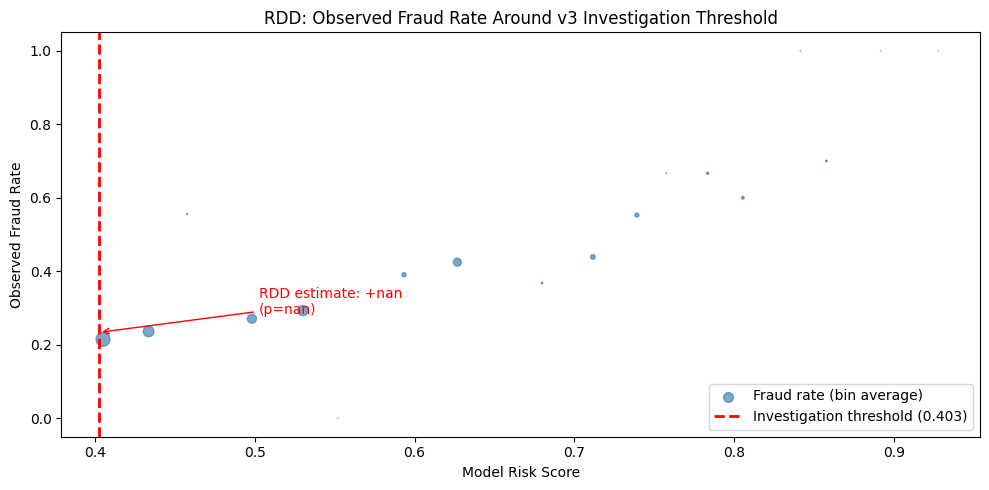

Saved: rdd_discontinuity.png


In [8]:
plot_rdd(rdd_result, title="RDD: Observed Fraud Rate Around v3 Investigation Threshold")

## A.4 PSM — ATE of investigation against TRUE fraud

**EN:** We can use `true_fraud` as the outcome (a simulation-only luxury) to ask: does investigation truly find more fraud than non-investigation, after matching on observables? Positive ATE = investigation *creates* the label (loop). Near-zero ATE = investigation finds existing fraud.

**KR:** `true_fraud`를 결과 변수로 사용(시뮬레이션에서만 가능): 관측변수 매칭 후, 조사가 미조사보다 실제로 fraud를 더 많이 찾는가? 양의 ATE = 조사가 **라벨을 만듬**(루프). 0에 가까운 ATE = 조사가 기존 fraud를 발견.

In [9]:
psm_result = propensity_score_matching(
    df=df,
    treatment_col='investigated',
    outcome_col='true_fraud_float',
    feature_cols=feature_cols,
    caliper=0.10,
)

if 'error' in psm_result:
    print(f"❌ {psm_result['error']}")
else:
    print("📊 PSM Result:")
    for k, v in psm_result.items():
        if k != 'interpretation':
            print(f"  {k:<24}: {v}")
    print()
    print(f"💡 Interpretation: {psm_result['interpretation']}")

❌ No matches found within caliper. Try increasing caliper or caliper=None.


## A.5 (Optional) DiD — Pre/Post v1 vs v2 deployment

**EN:** Treats v1 era and v2 era as pre/post. Treated = above threshold, control = below. Significant DiD = the version change shifted fraud patterns beyond background drift.

**KR:** v1 시대 vs v2 시대를 사전/사후로 취급. Treated = 임계값 위, control = 아래. 유의한 DiD = 버전 교체가 background drift를 넘어 fraud 패턴을 이동.

In [10]:
# Tag each row by which version "investigated" it
df['model_period'] = np.where(df['model_v1_investigated'] == 1, 'v1', 'v2')
df_with_outcome = df.dropna(subset=['observed_fraud']).copy()

did_result = difference_in_differences(
    df=df_with_outcome,
    version_col='model_period',
    pre_version='v1', post_version='v2',
    treatment_col='above_threshold',
    outcome_col='observed_fraud',
)

print("📊 DiD Result:")
for k, v in did_result.items():
    if k != 'interpretation':
        print(f"  {k:<24}: {v}")
print()
print(f"💡 Interpretation: {did_result['interpretation']}")

📊 DiD Result:
  y_treated_pre           : 0.3045
  y_treated_post          : 0.2195
  y_control_pre           : nan
  y_control_post          : nan
  did_estimate            : nan
  std_error               : nan
  z_statistic             : 0
  p_value                 : 1.0
  significant             : False

💡 Interpretation: Model version change did NOT significantly shift fraud detection by +nan (p=1.000)


## 🎯 What you should observe

**EN:**
- **RDD**: significant positive jump at threshold → investigation causally inflates observed fraud rate
- **PSM**: positive ATE (treated > control on true_fraud) → investigation indeed finds *more* fraud, but the gap relative to ground-truth diff tells us the inflation
- **DiD**: version change should shift the treated group more than control if the loop is reinforcing

**KR:**
- **RDD**: 임계값에서 유의한 양의 점프 → 조사가 인과적으로 observed fraud rate를 부풀림
- **PSM**: 양의 ATE (treated가 true_fraud에서 control 초과) → 조사가 실제로 fraud를 **더** 찾지만, ground truth 차이 대비 격차가 인플레이션 크기를 보여줌
- **DiD**: 루프가 강화 중이라면 버전 교체가 treated 그룹을 control보다 더 크게 이동시켜야 함